# Training Models Using Selected Features

In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_train_selected.parquet"
)

X_test = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_test_selected.parquet"
)

y_train = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/y_train_selected.parquet"
)["Label"]

y_test = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/y_test_selected.parquet"
)["Label"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1785379, 43)
X_test : (446345, 43)
y_train: (1785379,)
y_test : (446345,)


In [2]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(y_train.nunique())
)

print("y_test shape:", y_test.shape)
print("y_test_bin shape:", y_test_bin.shape)

y_test shape: (446345,)
y_test_bin shape: (446345, 15)


## 1. Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_after = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_after.fit(X_train, y_train)

y_pred_rf_after = rf_after.predict(X_test)
y_prob_rf_after = rf_after.predict_proba(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [4]:
import joblib

joblib.dump(
    rf_after,
    "/kaggle/working/rf_selected_model.pkl"
)

print("Random Forest selected-feature model saved.")

Random Forest selected-feature model saved.


In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_rf_after)

precision_weighted = precision_score(
    y_test, y_pred_rf_after,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test, y_pred_rf_after,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_test, y_pred_rf_after,
    average="weighted",
    zero_division=0
)

precision_macro = precision_score(
    y_test, y_pred_rf_after,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test, y_pred_rf_after,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test, y_pred_rf_after,
    average="macro",
    zero_division=0
)

mcc = matthews_corrcoef(y_test, y_pred_rf_after)

auc = roc_auc_score(
    y_test_bin,
    y_prob_rf_after,
    multi_class="ovr",
    average="weighted"
)

rf_selected_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "MCC",
        "AUC"
    ],
    "Value": [
        accuracy,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        precision_macro,
        recall_macro,
        f1_macro,
        mcc,
        auc
    ]
})

print(rf_selected_results)

rf_selected_results.to_csv(
    "/kaggle/working/rf_selected_results.csv",
    index=False
)

               Metric     Value
0            Accuracy  0.998510
1  Weighted Precision  0.998459
2     Weighted Recall  0.998510
3         Weighted F1  0.998470
4     Macro Precision  0.927352
5        Macro Recall  0.832069
6            Macro F1  0.859371
7                 MCC  0.994467
8                 AUC  0.999865


In [6]:
rf_selected_predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf_after
})

rf_selected_predictions.to_csv(
    "/kaggle/working/rf_selected_predictions.csv",
    index=False
)

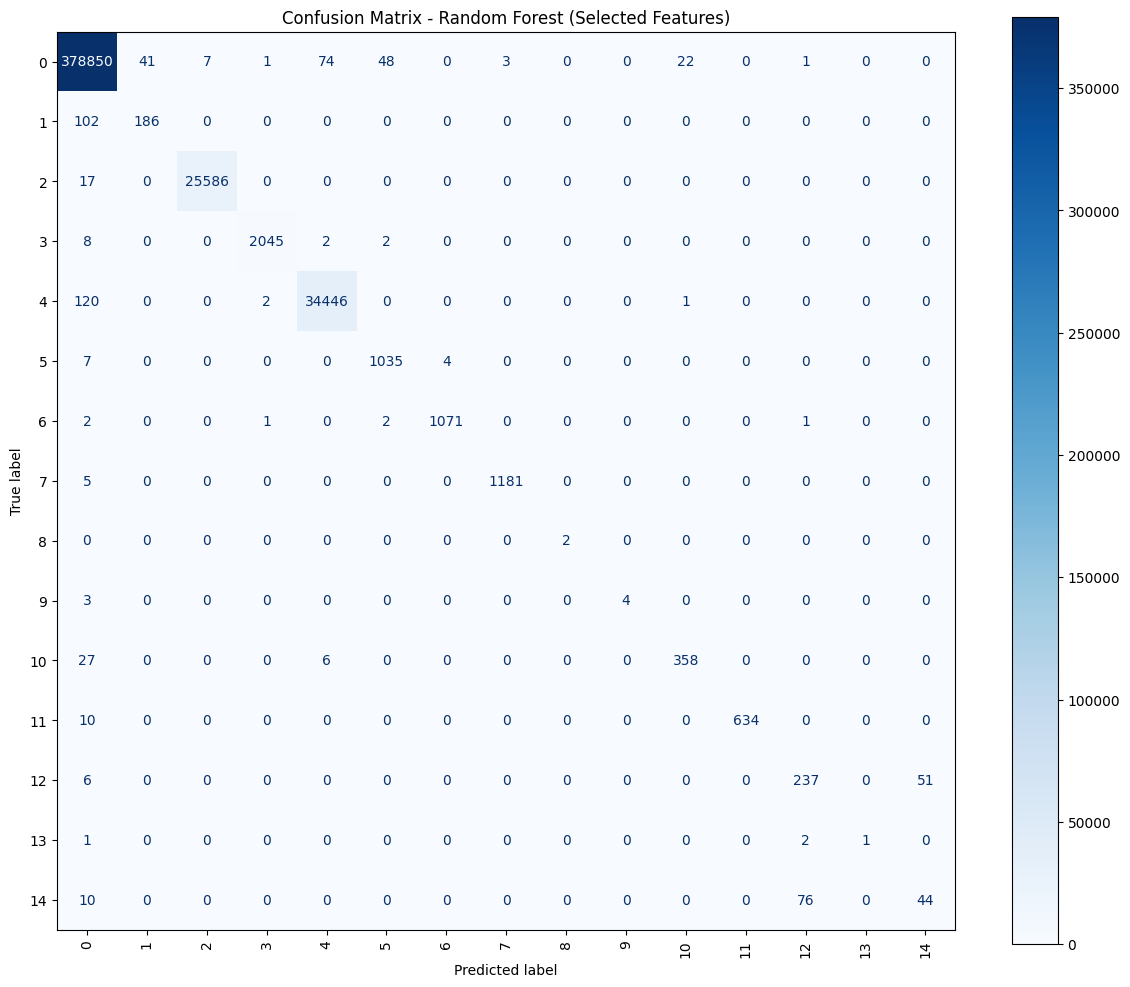

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf_after)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True
)

plt.title("Confusion Matrix - Random Forest (Selected Features)")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/rf_selected_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2. LightGBM 

In [8]:
from lightgbm import LGBMClassifier

lgbm_after = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

lgbm_after.fit(X_train, y_train)

y_pred_lgbm_after = lgbm_after.predict(X_test)
y_prob_lgbm_after = lgbm_after.predict_proba(X_test)

print("LightGBM training completed.")

LightGBM training completed.


In [9]:
joblib.dump(
    lgbm_after,
    "/kaggle/working/lgbm_selected_model.pkl"
)

print("LightGBM selected-feature model saved.")

LightGBM selected-feature model saved.


In [10]:
accuracy = accuracy_score(y_test, y_pred_lgbm_after)

precision_weighted = precision_score(
    y_test, y_pred_lgbm_after,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test, y_pred_lgbm_after,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_test, y_pred_lgbm_after,
    average="weighted",
    zero_division=0
)

precision_macro = precision_score(
    y_test, y_pred_lgbm_after,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test, y_pred_lgbm_after,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test, y_pred_lgbm_after,
    average="macro",
    zero_division=0
)

mcc = matthews_corrcoef(y_test, y_pred_lgbm_after)

auc = roc_auc_score(
    y_test_bin,
    y_prob_lgbm_after,
    multi_class="ovr",
    average="weighted"
)

lgbm_selected_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "MCC",
        "AUC"
    ],
    "Value": [
        accuracy,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        precision_macro,
        recall_macro,
        f1_macro,
        mcc,
        auc
    ]
})

lgbm_selected_results.to_csv(
    "/kaggle/working/lgbm_selected_results.csv",
    index=False
)

print(lgbm_selected_results)

               Metric     Value
0            Accuracy  0.849663
1  Weighted Precision  0.894872
2     Weighted Recall  0.849663
3         Weighted F1  0.868465
4     Macro Precision  0.166693
5        Macro Recall  0.176575
6            Macro F1  0.167906
7                 MCC  0.534280
8                 AUC  0.823932


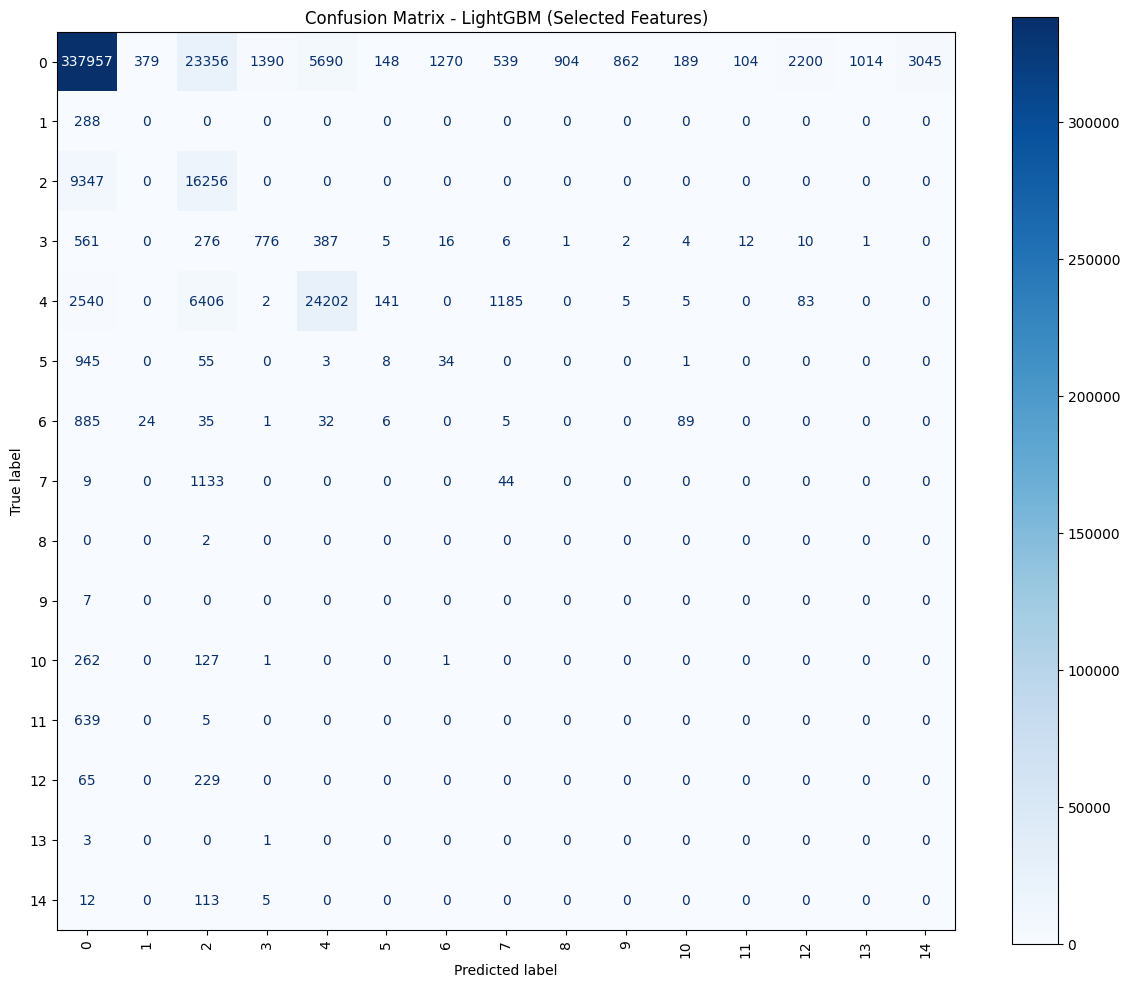

In [11]:
lgbm_selected_predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lgbm_after
})

lgbm_selected_predictions.to_csv(
    "/kaggle/working/lgbm_selected_predictions.csv",
    index=False
)

cm = confusion_matrix(y_test, y_pred_lgbm_after)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True
)

plt.title("Confusion Matrix - LightGBM (Selected Features)")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/lgbm_selected_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. CatBoost

In [12]:
from catboost import CatBoostClassifier

cat_after = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    random_seed=42,
    verbose=0
)

cat_after.fit(X_train, y_train)

y_pred_cat_after = cat_after.predict(X_test).ravel()
y_prob_cat_after = cat_after.predict_proba(X_test)

print("CatBoost training completed.")

CatBoost training completed.


In [13]:
joblib.dump(
    cat_after,
    "/kaggle/working/catboost_selected_model.pkl"
)

print("CatBoost selected-feature model saved.")

CatBoost selected-feature model saved.


In [14]:
accuracy = accuracy_score(y_test, y_pred_cat_after)

precision_weighted = precision_score(
    y_test, y_pred_cat_after,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test, y_pred_cat_after,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_test, y_pred_cat_after,
    average="weighted",
    zero_division=0
)

precision_macro = precision_score(
    y_test, y_pred_cat_after,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test, y_pred_cat_after,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test, y_pred_cat_after,
    average="macro",
    zero_division=0
)

mcc = matthews_corrcoef(y_test, y_pred_cat_after)

auc = roc_auc_score(
    y_test_bin,
    y_prob_cat_after,
    multi_class="ovr",
    average="weighted"
)

cat_selected_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "MCC",
        "AUC"
    ],
    "Value": [
        accuracy,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        precision_macro,
        recall_macro,
        f1_macro,
        mcc,
        auc
    ]
})

cat_selected_results.to_csv(
    "/kaggle/working/catboost_selected_results.csv",
    index=False
)

print(cat_selected_results.to_string(index=False))

            Metric    Value
          Accuracy 0.998071
Weighted Precision 0.998130
   Weighted Recall 0.998071
       Weighted F1 0.997893
   Macro Precision 0.901801
      Macro Recall 0.725109
          Macro F1 0.748347
               MCC 0.992830
               AUC 0.999934


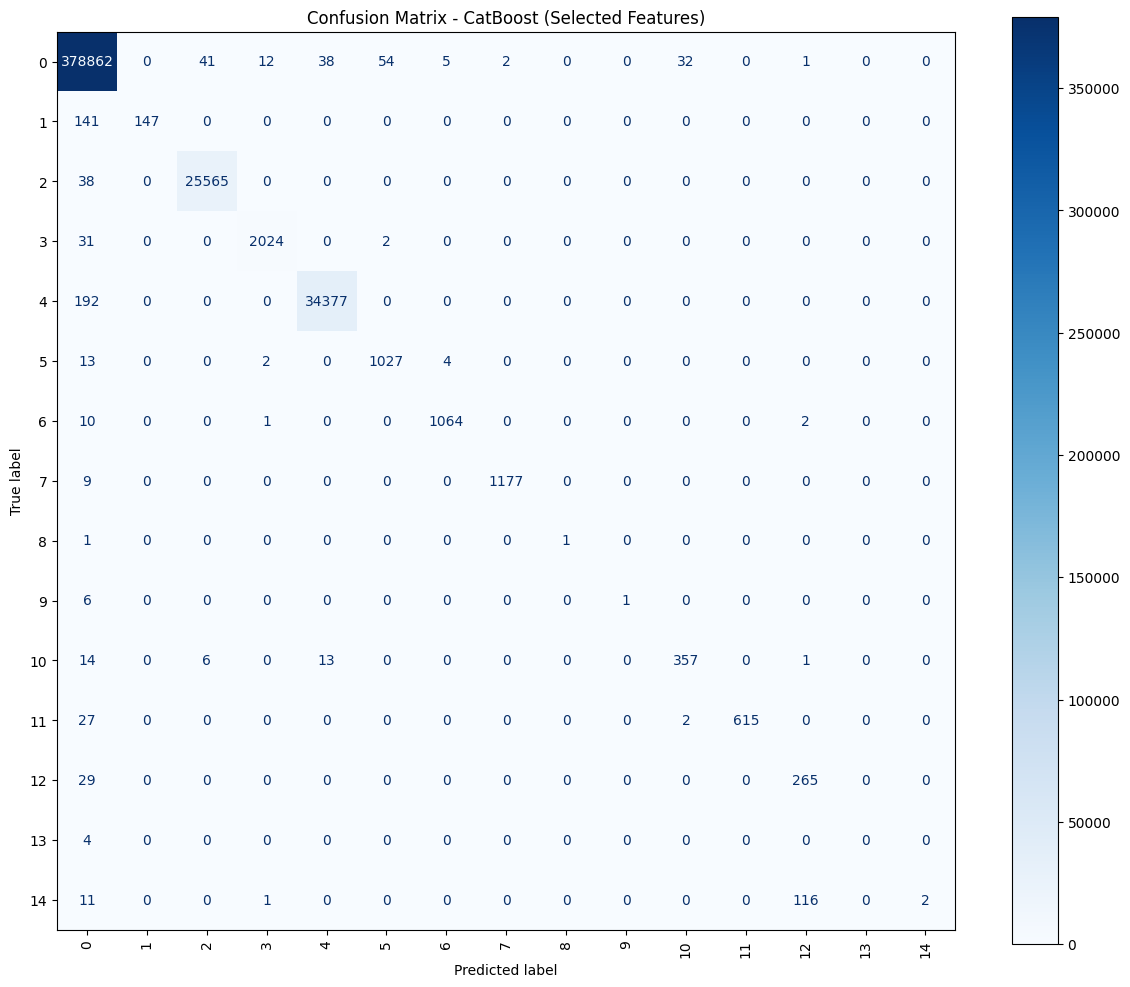

In [15]:
cat_selected_predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_cat_after
})

cat_selected_predictions.to_csv(
    "/kaggle/working/catboost_selected_predictions.csv",
    index=False
)

cm = confusion_matrix(y_test, y_pred_cat_after)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True
)

plt.title("Confusion Matrix - CatBoost (Selected Features)")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/catboost_selected_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. XGBoost

In [16]:
from xgboost import XGBClassifier

xgb_after = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=y_train.nunique(),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("Training XGBoost on 43 Boruta-selected features...")

xgb_after.fit(X_train, y_train)

y_pred_xgb_after = xgb_after.predict(X_test)
y_prob_xgb_after = xgb_after.predict_proba(X_test)

print("XGBoost 43-feature training completed.")
print("Prediction shape:", y_pred_xgb_after.shape)

Training XGBoost on 43 Boruta-selected features...
XGBoost 43-feature training completed.
Prediction shape: (446345,)


In [17]:
joblib.dump(
    xgb_after,
    "/kaggle/working/xgb_selected_model.pkl"
)

print("XGBoost selected-feature model saved.")

XGBoost selected-feature model saved.


In [18]:
accuracy = accuracy_score(y_test, y_pred_xgb_after)

precision_weighted = precision_score(
    y_test, y_pred_xgb_after,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test, y_pred_xgb_after,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_test, y_pred_xgb_after,
    average="weighted",
    zero_division=0
)

precision_macro = precision_score(
    y_test, y_pred_xgb_after,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test, y_pred_xgb_after,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test, y_pred_xgb_after,
    average="macro",
    zero_division=0
)

mcc = matthews_corrcoef(y_test, y_pred_xgb_after)

auc = roc_auc_score(
    y_test_bin,
    y_prob_xgb_after,
    multi_class="ovr",
    average="weighted"
)

xgb_selected_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "MCC",
        "AUC"
    ],
    "Value": [
        accuracy,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        precision_macro,
        recall_macro,
        f1_macro,
        mcc,
        auc
    ]
})

xgb_selected_results.to_csv(
    "/kaggle/working/xgb_selected_results.csv",
    index=False
)

print(xgb_selected_results.to_string(index=False))

            Metric    Value
          Accuracy 0.998497
Weighted Precision 0.998482
   Weighted Recall 0.998497
       Weighted F1 0.998359
   Macro Precision 0.955202
      Macro Recall 0.825275
          Macro F1 0.850269
               MCC 0.994414
               AUC 0.999968


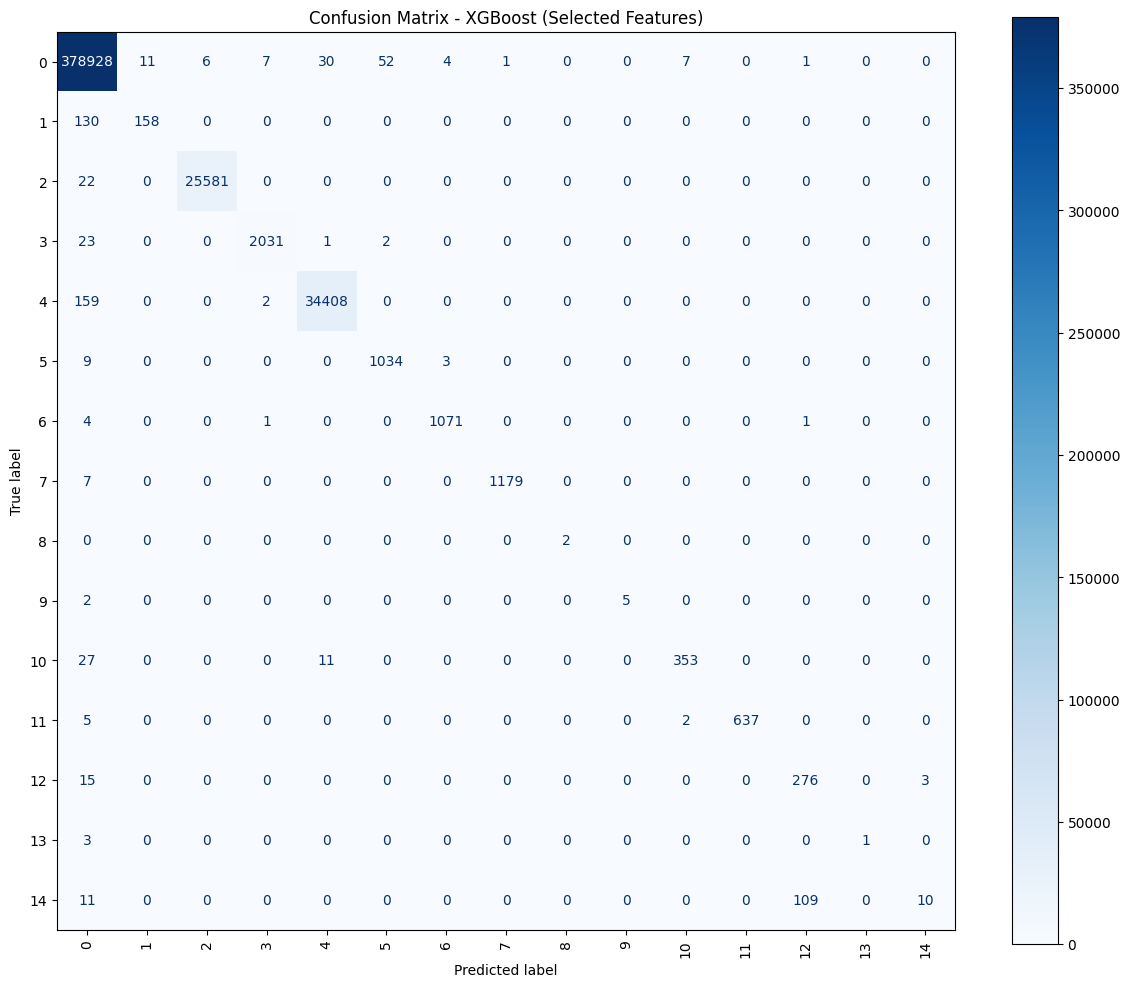

In [19]:
xgb_selected_predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_xgb_after
})

xgb_selected_predictions.to_csv(
    "/kaggle/working/xgb_selected_predictions.csv",
    index=False
)

cm = confusion_matrix(y_test, y_pred_xgb_after)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True
)

plt.title("Confusion Matrix - XGBoost (Selected Features)")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/xgb_selected_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Selected-Feature Model Comparison

In [20]:
selected_model_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "LightGBM",
        "CatBoost",
        "XGBoost"
    ],
    "Accuracy": [
        rf_selected_results.loc[
            rf_selected_results["Metric"] == "Accuracy", "Value"
        ].iloc[0],
        lgbm_selected_results.loc[
            lgbm_selected_results["Metric"] == "Accuracy", "Value"
        ].iloc[0],
        cat_selected_results.loc[
            cat_selected_results["Metric"] == "Accuracy", "Value"
        ].iloc[0],
        xgb_selected_results.loc[
            xgb_selected_results["Metric"] == "Accuracy", "Value"
        ].iloc[0]
    ],
    "Weighted Precision": [
        rf_selected_results.loc[rf_selected_results["Metric"] == "Weighted Precision", "Value"].iloc[0],
        lgbm_selected_results.loc[lgbm_selected_results["Metric"] == "Weighted Precision", "Value"].iloc[0],
        cat_selected_results.loc[cat_selected_results["Metric"] == "Weighted Precision", "Value"].iloc[0],
        xgb_selected_results.loc[xgb_selected_results["Metric"] == "Weighted Precision", "Value"].iloc[0]
    ],
    "Weighted Recall": [
        rf_selected_results.loc[rf_selected_results["Metric"] == "Weighted Recall", "Value"].iloc[0],
        lgbm_selected_results.loc[lgbm_selected_results["Metric"] == "Weighted Recall", "Value"].iloc[0],
        cat_selected_results.loc[cat_selected_results["Metric"] == "Weighted Recall", "Value"].iloc[0],
        xgb_selected_results.loc[xgb_selected_results["Metric"] == "Weighted Recall", "Value"].iloc[0]
    ],
    "Weighted F1": [
        rf_selected_results.loc[rf_selected_results["Metric"] == "Weighted F1", "Value"].iloc[0],
        lgbm_selected_results.loc[lgbm_selected_results["Metric"] == "Weighted F1", "Value"].iloc[0],
        cat_selected_results.loc[cat_selected_results["Metric"] == "Weighted F1", "Value"].iloc[0],
        xgb_selected_results.loc[xgb_selected_results["Metric"] == "Weighted F1", "Value"].iloc[0]
    ],
    "Macro Precision": [
        rf_selected_results.loc[rf_selected_results["Metric"] == "Macro Precision", "Value"].iloc[0],
        lgbm_selected_results.loc[lgbm_selected_results["Metric"] == "Macro Precision", "Value"].iloc[0],
        cat_selected_results.loc[cat_selected_results["Metric"] == "Macro Precision", "Value"].iloc[0],
        xgb_selected_results.loc[xgb_selected_results["Metric"] == "Macro Precision", "Value"].iloc[0]
    ],
    "Macro Recall": [
        rf_selected_results.loc[rf_selected_results["Metric"] == "Macro Recall", "Value"].iloc[0],
        lgbm_selected_results.loc[lgbm_selected_results["Metric"] == "Macro Recall", "Value"].iloc[0],
        cat_selected_results.loc[cat_selected_results["Metric"] == "Macro Recall", "Value"].iloc[0],
        xgb_selected_results.loc[xgb_selected_results["Metric"] == "Macro Recall", "Value"].iloc[0]
    ],
    "Macro F1": [
        rf_selected_results.loc[rf_selected_results["Metric"] == "Macro F1", "Value"].iloc[0],
        lgbm_selected_results.loc[lgbm_selected_results["Metric"] == "Macro F1", "Value"].iloc[0],
        cat_selected_results.loc[cat_selected_results["Metric"] == "Macro F1", "Value"].iloc[0],
        xgb_selected_results.loc[xgb_selected_results["Metric"] == "Macro F1", "Value"].iloc[0]
    ],
    "MCC": [
        rf_selected_results.loc[rf_selected_results["Metric"] == "MCC", "Value"].iloc[0],
        lgbm_selected_results.loc[lgbm_selected_results["Metric"] == "MCC", "Value"].iloc[0],
        cat_selected_results.loc[cat_selected_results["Metric"] == "MCC", "Value"].iloc[0],
        xgb_selected_results.loc[xgb_selected_results["Metric"] == "MCC", "Value"].iloc[0]
    ],
    "AUC": [
        rf_selected_results.loc[rf_selected_results["Metric"] == "AUC", "Value"].iloc[0],
        lgbm_selected_results.loc[lgbm_selected_results["Metric"] == "AUC", "Value"].iloc[0],
        cat_selected_results.loc[cat_selected_results["Metric"] == "AUC", "Value"].iloc[0],
        xgb_selected_results.loc[xgb_selected_results["Metric"] == "AUC", "Value"].iloc[0]
    ]
})

display(selected_model_results.round(6))

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,MCC,AUC
0,Random Forest,0.998510,0.998459,0.998510,0.998470,0.927352,0.832069,0.859371,0.994467,0.999865
1,LightGBM,0.849663,0.894872,0.849663,0.868465,0.166693,0.176575,0.167906,0.534280,0.823932
2,CatBoost,0.998071,0.998130,0.998071,0.997893,0.901801,0.725109,0.748347,0.992830,0.999934
3,XGBoost,0.998497,0.998482,0.998497,0.998359,0.955202,0.825275,0.850269,0.994414,0.999968


In [21]:
clear_comparison = selected_model_results.set_index("Model").T
clear_comparison = clear_comparison.round(6)

display(clear_comparison)

Model,Random Forest,LightGBM,CatBoost,XGBoost
Accuracy,0.998510,0.849663,0.998071,0.998497
Weighted Precision,0.998459,0.894872,0.998130,0.998482
Weighted Recall,0.998510,0.849663,0.998071,0.998497
Weighted F1,0.998470,0.868465,0.997893,0.998359
Macro Precision,0.927352,0.166693,0.901801,0.955202
Macro Recall,0.832069,0.176575,0.725109,0.825275
Macro F1,0.859371,0.167906,0.748347,0.850269
MCC,0.994467,0.534280,0.992830,0.994414
AUC,0.999865,0.823932,0.999934,0.999968


In [22]:
selected_model_results.to_csv(
    "/kaggle/working/selected_features_model_comparison.csv",
    index=False
)

print("Final selected-feature comparison saved.")

Final selected-feature comparison saved.
